
DOWNLOAD NCBI

(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
"CNL"
OR
"TNL"
OR
"RLK"
OR
"RLP"
OR
"LECRK"
OR
"LYK"
OR
"NBS-LRR"
OR
"NB-LRR"
OR
"plant resistance gene"
OR
"disease resistance protein"
OR
"immune receptor"
OR
"viral resistance"
OR
"antiviral protein"
OR
"Tobamovirus"
OR
"TMV"
OR
"ToMV"
OR
"RNA silencing"
OR
"hypersensitive response"
)
NOT
(
partial
OR
hypothetical
OR
predicted
OR 
genome
OR
scaffold
OR
contig
OR
assembly
)

IDs encontrados: 786
Arquivo salvo: pipeline_rgenes/positive.fasta

DOWNLOAD NCBI

(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
"actin"
OR
"tubulin"
OR
"ribosomal protein"
OR
"photosystem"
OR
"ATP synthase"
OR
"metabolic enzyme"
)
NOT
(
"resistance"
OR
"NBS"
OR
"LRR"
OR
"immune"
OR
"virus"
)

IDs encontrados: 1500
Arquivo salvo: pipeline_rgenes/negative.fasta

Arquivo: pipeline_rgenes/positive.fasta
Total: 786
Válidas: 208

Arquivo: pipeline_rgenes/negative.fasta
Total: 1500
Válidas: 

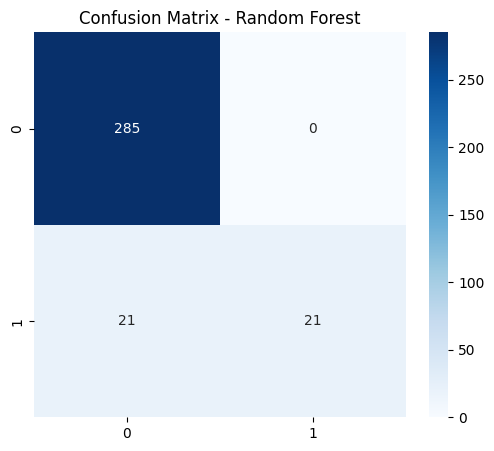

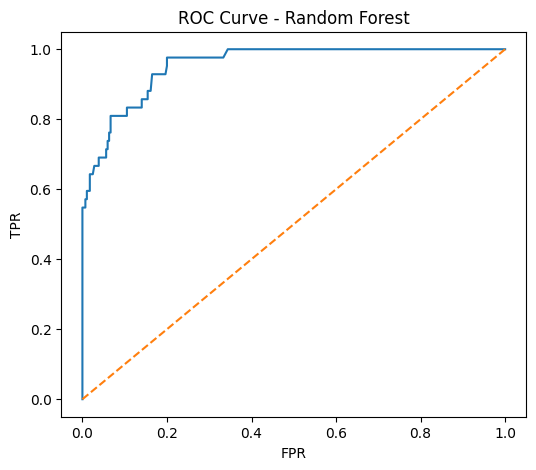



XGBoost
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       285
           1       1.00      0.57      0.73        42

    accuracy                           0.94       327
   macro avg       0.97      0.79      0.85       327
weighted avg       0.95      0.94      0.94       327

ROC-AUC: 0.9617376775271512
PR-AUC : 0.8538498778374287
MCC    : 0.733131856940167
F1     : 0.7272727272727273


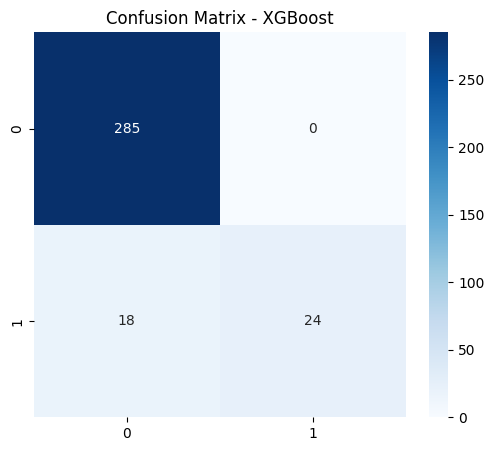

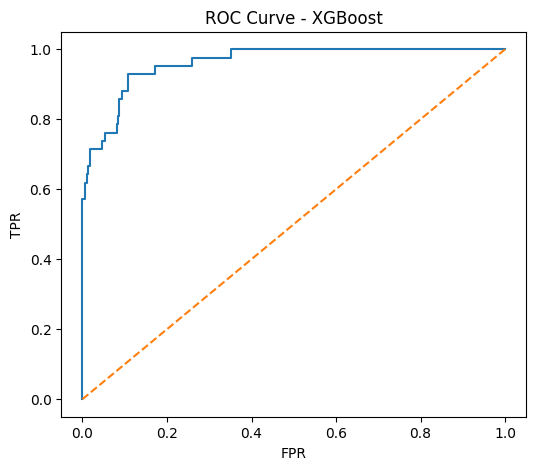


RF ROC-AUC: 0.9586487638734109
XGB ROC-AUC: 0.9657442172718167


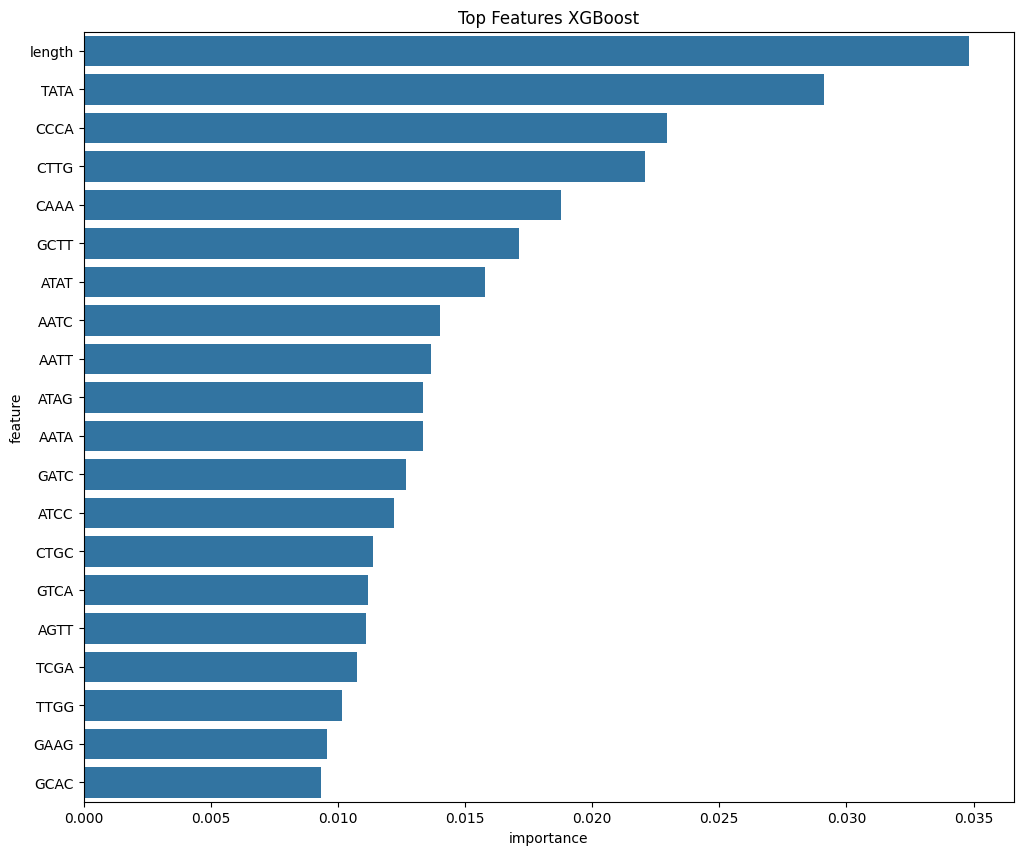


Executando PCA...


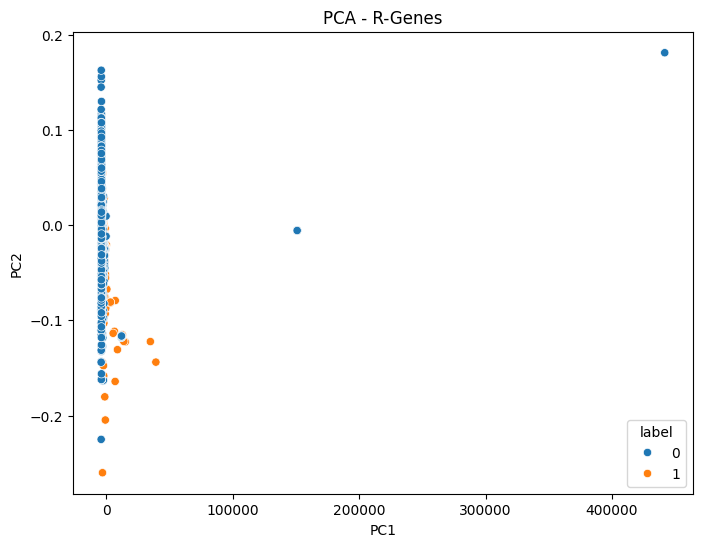


Executando UMAP...


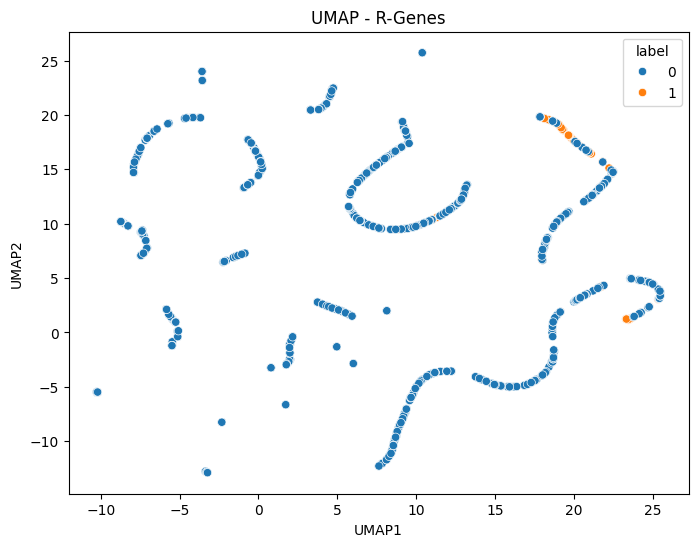


Executando KMeans...

KMeans
Silhouette: 0.9926236338683758
Davies-Bouldin: 0.10383253587742151


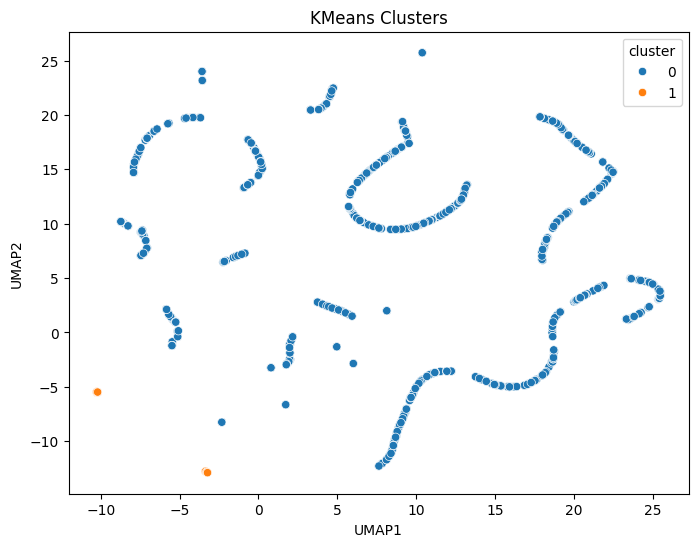


Executando HDBSCAN...


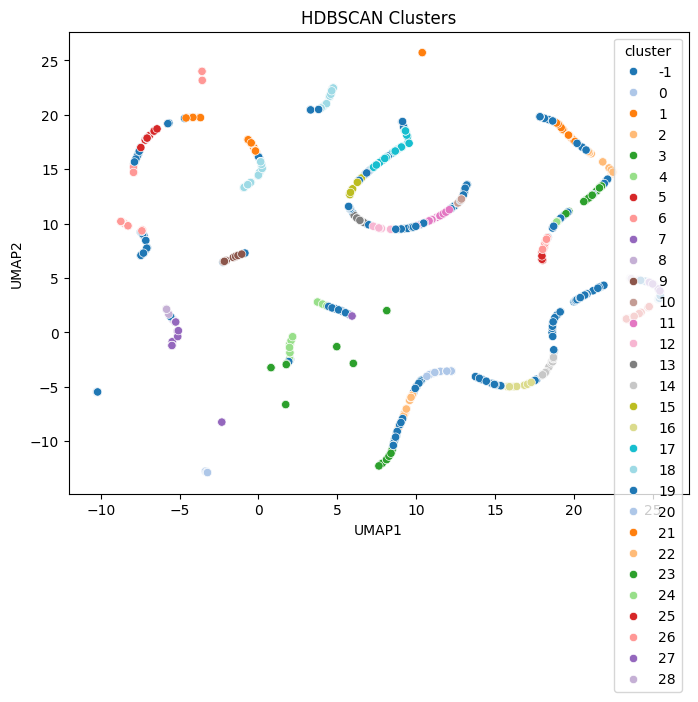


DOWNLOAD NCBI

"Physalis peruviana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
)

IDs encontrados: 1000
Arquivo salvo: pipeline_rgenes/physalis.fasta

DOWNLOAD NCBI

"Arabidopsis thaliana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
OR
CDS
OR
transcript
OR
cDNA
)

IDs encontrados: 1000
Arquivo salvo: pipeline_rgenes/arabidopsis.fasta

TOP CANDIDATOS PHYSALIS
                    id                                          descricao  \
557        NR_143334.1  NR_143334.1 Arabidopsis thaliana other RNA (AT...   
558        NR_143333.1  NR_143333.1 Arabidopsis thaliana other RNA (AT...   
212         PP829210.1  PP829210.1 Arabidopsis thaliana ribulose bisph...   
525        NR_143023.1  NR_143023.1 Arabidopsis thaliana other RNA (AT...   
669        NR_144176.1  NR_144176.1 Arabidopsis thaliana uncharacteriz...   
555        NR_143336.1  NR_143336.1 Arabidopsis thaliana other RNA (AT...   
90          AB682895.1  AB682895.1 Arabidopsis thaliana gene for recep...   
166        

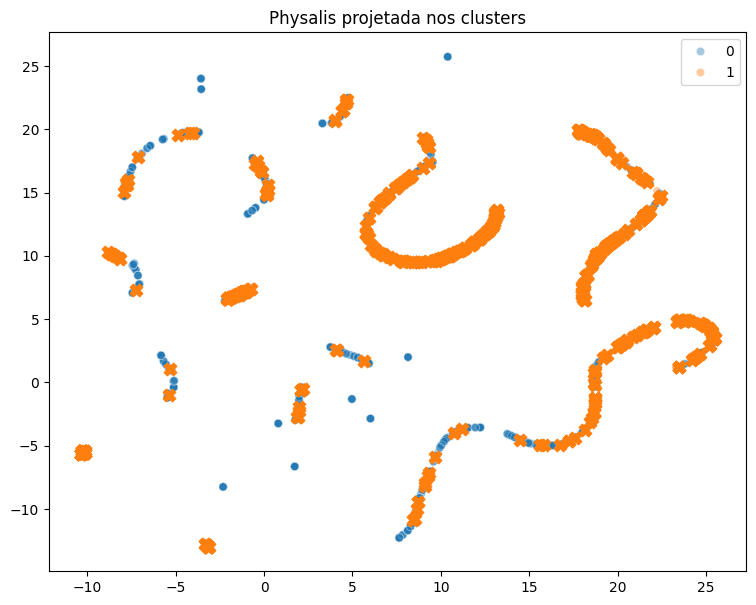


PIPELINE FINALIZADO


In [6]:
# ==========================================================
# PIPELINE COMPLETO
# MACHINE LEARNING + CLUSTERING
# GENES DE RESISTÊNCIA EM PHYSALIS PERUVIANA
# ==========================================================

import os
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from Bio import Entrez
from Bio import SeqIO

# ==========================================================
# ML
# ==========================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    matthews_corrcoef,
    f1_score,
    silhouette_score,
    davies_bouldin_score
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# ==========================================================
# CLUSTERING
# ==========================================================

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

import umap
import hdbscan

# ==========================================================
# VISUALIZAÇÃO
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# CONFIG
# ==========================================================

Entrez.email = "marcela.leite@ifc.edu.br"

OUTPUT_DIR = "pipeline_rgenes"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# DOWNLOAD NCBI
# ==========================================================

def baixar_fasta_ncbi(query, arquivo_saida, max_records=1500):

    print("\n===================================")
    print("DOWNLOAD NCBI")
    print("===================================")

    print(query)

    handle = Entrez.esearch(
        db="nucleotide",
        term=query,
        retmax=max_records
    )

    record = Entrez.read(handle)

    ids = record["IdList"]

    print("IDs encontrados:", len(ids))

    if len(ids) == 0:
        return

    handle = Entrez.efetch(
        db="nucleotide",
        id=ids,
        rettype="fasta",
        retmode="text"
    )

    fasta = handle.read()

    with open(arquivo_saida, "w") as f:
        f.write(fasta)

    print("Arquivo salvo:", arquivo_saida)

# ==========================================================
# QUERY POSITIVA
# ==========================================================

positive_query = """
(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
"CNL"
OR
"TNL"
OR
"RLK"
OR
"RLP"
OR
"LECRK"
OR
"LYK"
OR
"NBS-LRR"
OR
"NB-LRR"
OR
"plant resistance gene"
OR
"disease resistance protein"
OR
"immune receptor"
OR
"viral resistance"
OR
"antiviral protein"
OR
"Tobamovirus"
OR
"TMV"
OR
"ToMV"
OR
"RNA silencing"
OR
"hypersensitive response"
)
NOT
(
partial
OR
hypothetical
OR
predicted
OR 
genome
OR
scaffold
OR
contig
OR
assembly
)
"""

# ==========================================================
# QUERY NEGATIVA
# ==========================================================

negative_query = """
(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
"actin"
OR
"tubulin"
OR
"ribosomal protein"
OR
"photosystem"
OR
"ATP synthase"
OR
"metabolic enzyme"
)
NOT
(
"resistance"
OR
"NBS"
OR
"LRR"
OR
"immune"
OR
"virus"
)
"""

# ==========================================================
# DOWNLOADS
# ==========================================================

baixar_fasta_ncbi(
    positive_query,
    f"{OUTPUT_DIR}/positive.fasta"
)

baixar_fasta_ncbi(
    negative_query,
    f"{OUTPUT_DIR}/negative.fasta"
)

# ==========================================================
# K-MERS
# ==========================================================

K = 4

NUCLEOTIDES = ['A','T','C','G']

ALL_KMERS = [
    ''.join(p)
    for p in itertools.product(NUCLEOTIDES, repeat=K)
]

# ==========================================================
# LIMPEZA
# ==========================================================

def limpar_seq(seq):

    seq = seq.upper()

    valid = set("ATCG")

    seq = "".join([
        x for x in seq
        if x in valid
    ])

    return seq

# ==========================================================
# GC
# ==========================================================

def calcular_gc(seq):

    gc = seq.count("G") + seq.count("C")

    return gc / len(seq)

# ==========================================================
# ENTROPIA
# ==========================================================

def calcular_entropia(seq):

    probs = []

    for n in "ATCG":

        p = seq.count(n) / len(seq)

        if p > 0:
            probs.append(p)

    entropy = -sum([
        p * np.log2(p)
        for p in probs
    ])

    return entropy

# ==========================================================
# K-MERS
# ==========================================================

def contar_kmers(seq, k=4):

    counts = dict.fromkeys(ALL_KMERS, 0)

    total = len(seq) - k + 1

    if total <= 0:
        return [0]*len(ALL_KMERS)

    for i in range(total):

        kmer = seq[i:i+k]

        if kmer in counts:
            counts[kmer] += 1

    freqs = [
        counts[k]/total
        for k in ALL_KMERS
    ]

    return freqs

# ==========================================================
# FEATURES
# ==========================================================

def extract_features(seq):

    seq = limpar_seq(seq)

    if len(seq) < 300:
        return None

    try:

        kmers = contar_kmers(seq)

        gc = calcular_gc(seq)

        entropy = calcular_entropia(seq)

        length = len(seq)

        return kmers + [
            gc,
            entropy,
            length
        ]

    except:

        return None

# ==========================================================
# DATASET
# ==========================================================

X = []
y = []
ids = []

def processar_fasta(fasta, label):

    total = 0
    validas = 0

    for record in SeqIO.parse(fasta, "fasta"):

        total += 1

        desc = record.description.lower()

        if "partial" in desc:
            continue

        seq = str(record.seq)

        feats = extract_features(seq)

        if feats is not None:

            X.append(feats)

            y.append(label)

            ids.append(record.id)

            validas += 1

    print("\nArquivo:", fasta)
    print("Total:", total)
    print("Válidas:", validas)

# ==========================================================
# PROCESSAMENTO
# ==========================================================

processar_fasta(
    f"{OUTPUT_DIR}/positive.fasta",
    1
)

processar_fasta(
    f"{OUTPUT_DIR}/negative.fasta",
    0
)

# ==========================================================
# ARRAYS
# ==========================================================

X = np.array(X)

y = np.array(y)

print("\nDataset:", X.shape)

if len(X) == 0:
    raise ValueError("Nenhuma sequência válida.")

# ==========================================================
# DATAFRAME
# ==========================================================

columns = ALL_KMERS + [
    "gc_content",
    "entropy",
    "length"
]

df = pd.DataFrame(X, columns=columns)

df["label"] = y

df["id"] = ids

df.to_csv(
    f"{OUTPUT_DIR}/dataset_rgenes.csv",
    index=False
)

# ==========================================================
# TRAIN TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

# ==========================================================
# XGBOOST
# ==========================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

# ==========================================================
# AVALIAÇÃO
# ==========================================================

def avaliar_modelo(nome, y_true, pred, prob):

    print("\n")
    print("="*60)
    print(nome)
    print("="*60)

    print(classification_report(y_true, pred))

    auc = roc_auc_score(y_true, prob)

    pr_auc = average_precision_score(y_true, prob)

    mcc = matthews_corrcoef(y_true, pred)

    f1 = f1_score(y_true, pred)

    print("ROC-AUC:", auc)
    print("PR-AUC :", pr_auc)
    print("MCC    :", mcc)
    print("F1     :", f1)

    # ==========================================
    # MATRIZ CONFUSÃO
    # ==========================================

    cm = confusion_matrix(y_true, pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {nome}")

    plt.show()

    # ==========================================
    # ROC
    # ==========================================

    fpr, tpr, _ = roc_curve(y_true, prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr)

    plt.plot([0,1],[0,1],'--')

    plt.xlabel("FPR")

    plt.ylabel("TPR")

    plt.title(f"ROC Curve - {nome}")

    plt.show()

avaliar_modelo(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

avaliar_modelo(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

# ==========================================================
# CROSS VALIDATION
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

scores_xgb = cross_val_score(
    xgb,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("\nRF ROC-AUC:", scores_rf.mean())

print("XGB ROC-AUC:", scores_xgb.mean())

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "feature": columns,

    "importance": xgb.feature_importances_

})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.to_csv(
    f"{OUTPUT_DIR}/feature_importance.csv",
    index=False
)

plt.figure(figsize=(12,10))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top Features XGBoost")

plt.show()

# ==========================================================
# PCA
# ==========================================================

print("\nExecutando PCA...")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({

    "PC1": X_pca[:,0],

    "PC2": X_pca[:,1],

    "label": y

})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="label"
)

plt.title("PCA - R-Genes")

plt.show()

# ==========================================================
# UMAP
# ==========================================================

print("\nExecutando UMAP...")

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X)

umap_df = pd.DataFrame({

    "UMAP1": X_umap[:,0],

    "UMAP2": X_umap[:,1],

    "label": y

})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="label"
)

plt.title("UMAP - R-Genes")

plt.show()

# ==========================================================
# KMEANS
# ==========================================================

print("\nExecutando KMeans...")

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters_kmeans = kmeans.fit_predict(X)

sil = silhouette_score(X, clusters_kmeans)

db = davies_bouldin_score(X, clusters_kmeans)

print("\nKMeans")
print("Silhouette:", sil)
print("Davies-Bouldin:", db)

kmeans_df = pd.DataFrame({

    "UMAP1": X_umap[:,0],

    "UMAP2": X_umap[:,1],

    "cluster": clusters_kmeans

})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=kmeans_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette="tab10"
)

plt.title("KMeans Clusters")

plt.show()

# ==========================================================
# HDBSCAN
# ==========================================================

print("\nExecutando HDBSCAN...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15
)

clusters_hdb = clusterer.fit_predict(X)

hdb_df = pd.DataFrame({

    "UMAP1": X_umap[:,0],

    "UMAP2": X_umap[:,1],

    "cluster": clusters_hdb

})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=hdb_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette="tab20"
)

plt.title("HDBSCAN Clusters")

plt.show()

# ==========================================================
# PHYSALIS
# ==========================================================

physalis_query = """
"Physalis peruviana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
)
"""

baixar_fasta_ncbi(
    physalis_query,
    f"{OUTPUT_DIR}/physalis.fasta",
    1000
)

#########################################################

arabidopsis_query = """
"Arabidopsis thaliana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
OR
CDS
OR
transcript
OR
cDNA
)
"""

baixar_fasta_ncbi(
    arabidopsis_query,
    f"{OUTPUT_DIR}/arabidopsis.fasta",
    1000
)

########################################################

# ==========================================================
# PREDIÇÃO PHYSALIS
# ==========================================================

resultados = []

# for record in SeqIO.parse(
#     f"{OUTPUT_DIR}/physalis.fasta",
#     "fasta"
# ):

for record in SeqIO.parse(
    f"{OUTPUT_DIR}/arabidopsis.fasta",
    "fasta"
):


    seq = str(record.seq)

    feats = extract_features(seq)

    if feats is None:
        continue

    feats = np.array(feats).reshape(1,-1)

    prob = xgb.predict_proba(feats)[0][1]

    resultados.append({

        "id": record.id,

        "descricao": record.description,

        "probabilidade_resistencia": prob

    })

df_res = pd.DataFrame(resultados)

df_res = df_res.sort_values(
    by="probabilidade_resistencia",
    ascending=False
)

df_res.to_csv(
    # f"{OUTPUT_DIR}/predicoes_physalis.csv",
    f"{OUTPUT_DIR}/predicoes_arabidopsis.csv",
    index=False
)

print("\nTOP CANDIDATOS PHYSALIS")

print(df_res.head(20))

# ==========================================================
# PROJETAR PHYSALIS NO UMAP
# ==========================================================

X_phys = []

phys_ids = []

 # for record in SeqIO.parse(
 #     f"{OUTPUT_DIR}/physalis.fasta",
 #     "fasta"
 # ):
for record in SeqIO.parse(
     f"{OUTPUT_DIR}/arabidopsis.fasta",
     "fasta"
 ):

     seq = str(record.seq)

     feats = extract_features(seq)

     if feats is None:
         continue

     X_phys.append(feats)

     phys_ids.append(record.id)

X_phys = np.array(X_phys)

X_phys_umap = reducer.transform(X_phys)

phys_df = pd.DataFrame({

    "UMAP1": X_phys_umap[:,0],

    "UMAP2": X_phys_umap[:,1]

})

plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=y,
    alpha=0.4
)

plt.scatter(
    X_phys_umap[:,0],
    X_phys_umap[:,1],
    marker="X",
    s=80
)

plt.title(
    "Physalis projetada nos clusters"
)

plt.show()

# ==========================================================
# EXPORTAR CLUSTERS
# ==========================================================

cluster_export = pd.DataFrame({

    "id": ids,

    "label": y,

    "kmeans_cluster": clusters_kmeans,

    "hdbscan_cluster": clusters_hdb

})

cluster_export.to_csv(
    f"{OUTPUT_DIR}/clusters.csv",
    index=False
)

print("\nPIPELINE FINALIZADO")

